# Aim 1: Predicting TB Non-Conversion at Month 2 / Month 6

**Goal**: Predict which TB patients at baseline will not sputum-culture convert by months 2 and 5.

**Approach**:
- Build binary classifiers using baseline clinical and demographic features
- Target: `TARGET_NON_CONVERSION_ANY` (1 = non-converter, 0 = converter)
- Models: Logistic Regression, Random Forest, XGBoost
- Evaluation: Leave-One-Out CV (due to small sample size)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from src.data.feature_engineering import prepare_aim1_data
from src.models.train import train_models, get_champion_model
from src.models.evaluate import evaluate_model
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline


---
## 1. Load and Prepare Data

In [2]:
X_train, X_test, y_train, y_test, preprocessor, feature_cols = prepare_aim1_data(
    test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {feature_cols}")
print("\nTraining class distribution:")
print(y_train.value_counts() if len(y_train) > 0 else "No training data")

if len(X_train) > 0:
    # Show basic statistics
    print("\nFeature summary:")
    display(X_train.describe(include="all"))

Training samples: 174
Test samples: 44
Features: ['SEX', 'AGE (YEARS)', 'TEMPERATURE_CELCIUS', 'COUGH', 'FEVER', 'WEIGHT LOSS', 'NIGHT SWEATS', 'CHEST PAIN', 'HEMOPTYSIS', 'HIV_STATUS', 'HAS_DIABETES', 'SMOKES', 'CONSUMES_ALCOHOL', 'PAST_TB_DIAGNOSIS', 'TB_CONTACT', 'NUMBER_OF_OCCUPANTS', 'BMI', 'BASELINE_POSITIVE']

Training class distribution:
TARGET_NON_CONVERSION_ANY
0    169
1      5
Name: count, dtype: int64

Feature summary:


,SEX,AGE (YEARS),TEMPERATURE_CELCIUS,COUGH,FEVER,WEIGHT LOSS,NIGHT SWEATS,CHEST PAIN,HEMOPTYSIS,HIV_STATUS,HAS_DIABETES,SMOKES,CONSUMES_ALCOHOL,PAST_TB_DIAGNOSIS,TB_CONTACT,NUMBER_OF_OCCUPANTS,BMI,BASELINE_POSITIVE
count,174,174.000000,174.000000,174,174,174,174,174,174,174,174,174,174,174,174.000000,174.000000,174.000000,174.000000
unique,2,NaN,NaN,2,3,3,3,2,2,2,2,2,4,10,NaN,NaN,NaN,NaN
top,M,NaN,NaN,YES,YES,YES,YES,YES,NO,NO,NO,NO,NO,NO,NaN,NaN,NaN,NaN
freq,125,NaN,NaN,170,135,140,128,112,150,164,172,122,162,164,NaN,NaN,NaN,NaN
mean,NaN,32.563218,36.904598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.850575,1.821839,20.600377,0.971264
std,NaN,10.691903,0.699200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.971055,1.346108,4.007453,0.167545
min,NaN,18.000000,34.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,12.129337,0.000000
25%,NaN,25.000000,36.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,18.636921,1.000000
50%,NaN,30.000000,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,19.880755,1.000000
75%,NaN,38.000000,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,2.000000,21.551873,1.000000


---
## 2. Train Models with Cross-Validation

In [3]:
if len(X_train) >= 3:
    results, trained = train_models(
        X_train, y_train, preprocessor, feature_cols,
        aim="aim1_non_conversion",
        use_smote=(y_train.sum() > 0 and y_train.sum() < len(y_train)),
        cv_folds=min(5, len(X_train)),
        random_state=42,
    )
    
    print("\nModel Performance Summary:")
    summary = pd.DataFrame([
        {
            'Model': name,
            'Version': meta['version'],
            'Train AUC': f"{meta['train_auc']:.3f}",
            'CV AUC Mean': f"{meta['cv_auc_mean']:.3f}",
            'CV AUC Std': f"{meta['cv_auc_std']:.3f}",
        }
        for name, meta in results.items()
    ])
    display(summary)
    
    # Evaluate on test set
    if len(X_test) > 0:
        print("\n=== Test Set Evaluation ===")
        for name, (pipeline, _) in trained.items():
            evaluate_model(
                pipeline, X_test, y_test, name,
                "aim1_non_conversion", results[name]['version']
            )
else:
    print("Insufficient labeled samples for training.")

  logistic_regression (v55): CV AUC=nan ± nan, Train AUC=0.808


  random_forest (v56): CV AUC=nan ± nan, Train AUC=0.863


  xgboost (v57): CV AUC=nan ± nan, Train AUC=1.000

Model Performance Summary:


,Model,Version,Train AUC,CV AUC Mean,CV AUC Std
0,logistic_regression,v55,0.808,nan,nan
1,random_forest,v56,0.863,nan,nan
2,xgboost,v57,1.000,nan,nan



=== Test Set Evaluation ===
  logistic_regression (v55): Test AUC=0.163, F1=0.000, Recall=0.000


  random_forest (v56): Test AUC=0.930, F1=0.000, Recall=0.000


  xgboost (v57): Test AUC=0.581, F1=0.000, Recall=0.000


---
## 3. Leave-One-Out Cross-Validation for Small Data

In [4]:
if len(X_train) > 0 and len(X_train) <= 20:
    print(f"Running Leave-One-Out CV on {len(X_train)} samples...")
    
    loo = LeaveOneOut()
    loo_results = {}
    
    for name, (pipeline, _) in trained.items():
        y_true_loo, y_pred_loo = [], []
        for train_idx, test_idx in loo.split(X_train):
            X_loo_train = X_train.iloc[train_idx]
            y_loo_train = y_train.iloc[train_idx]
            X_loo_test = X_train.iloc[test_idx]
            y_loo_test = y_train.iloc[test_idx]
            
            p = Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', pipeline.named_steps['classifier']),
            ])
            p.fit(X_loo_train, y_loo_train)
            y_pred_loo.append(p.predict(X_loo_test)[0])
            y_true_loo.append(y_loo_test.values[0])
        
        accuracy = np.mean(np.array(y_true_loo) == np.array(y_pred_loo))
        loo_results[name] = {'LOO Accuracy': accuracy}
        print(f"  {name}: LOO Accuracy = {accuracy:.3f}")
    
    print("\nLOO CV suggests model stability with small data.")

---
## 4. Feature Importance (XGBoost)

Could not extract feature importance: index 25 is out of bounds for axis 0 with size 18


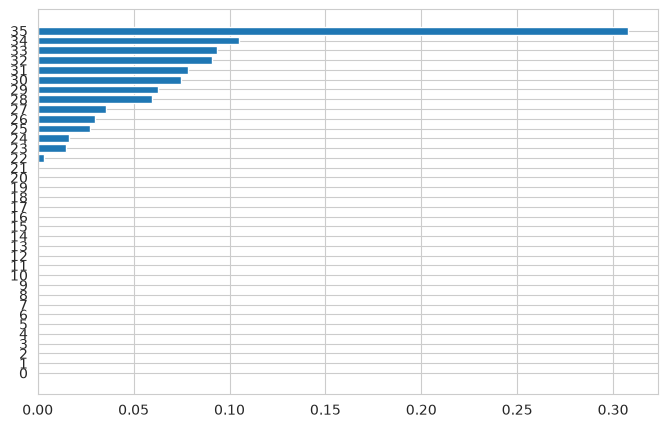

In [5]:
if 'xgboost' in trained:
    xgb_pipeline = trained['xgboost'][0]
    
    # Get feature names after preprocessing
    try:
        preprocessor_fitted = xgb_pipeline.named_steps['preprocessor']
        xgb_model = xgb_pipeline.named_steps['classifier']
        
        # Get feature importances
        importance = xgb_model.feature_importances_
        
        fig, ax = plt.subplots(figsize=(8, 5))
        idx = np.argsort(importance)
        ax.barh(range(len(importance)), importance[idx])
        ax.set_yticks(range(len(importance)))
        ax.set_yticklabels(np.array(feature_cols)[idx])
        ax.set_xlabel('Importance')
        ax.set_title('XGBoost Feature Importance')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not extract feature importance: {e}")

---
## 5. Conclusions & Next Steps

In [6]:
print("=== AIM 1 Summary ===")
print(f"\nData: {len(X_train)} training, {len(X_test)} test samples")
print(f"Features used: {len(feature_cols)}")
if len(X_train) >= 3:
    champion = get_champion_model('aim1_non_conversion')
    if champion:
        print(f"Champion model: {champion['model']} (v{champion['version']})")
        print(f"CV AUC: {champion['cv_auc_mean']:.3f} ± {champion['cv_auc_std']:.3f}")
    
print("\nKey limitations:")
print(f"1. Only {X_train is not None and len(X_train) or 0} labeled samples available")
print("2. Class imbalance present")
print("3. Results should be validated with more data")
print("\nRecommendations:")
print("1. Collect more sputum culture conversion outcomes")
print("2. Add FEND-TB cohort data when available")
print("3. Consider ensemble/staking for improved performance")

=== AIM 1 Summary ===

Data: 174 training, 44 test samples
Features used: 18
Champion model: random_forest (vv9)
CV AUC: 0.651 ± 0.232

Key limitations:
1. Only 174 labeled samples available
2. Class imbalance present
3. Results should be validated with more data

Recommendations:
1. Collect more sputum culture conversion outcomes
2. Add FEND-TB cohort data when available
3. Consider ensemble/staking for improved performance
